In [1]:
#pip install imageio

In [2]:
# PCA
# 画出解释方差曲线, 找到合适的保留大部分信息的拐点, 然后将这个点作为输入数据的341维度的目标降维维度

# 数据分割\

# 训练标签保存要方便加载

# 训练后也加入AUCPR

# 数据集划分验证

In [3]:
# 导入必要的库
import os
import time
from fastkan import *
from fastkan import FastKAN
import random
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt
import matplotlib.patches as mpts
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, cohen_kappa_score, accuracy_score
from sklearn.metrics import precision_score,precision_recall_curve, auc, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import balanced_accuracy_score, f1_score, cohen_kappa_score
from sklearn.preprocessing import minmax_scale
import pandas as pd
from scipy.io import loadmat
from tqdm.notebook import tqdm
from IPython import display
import h5py
import copy
import sys
import glob
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [4]:
## 超参数和实验设置配置单元格

# 设置随机种子，确保实验可重复性
RANDOM_SEED = 666

LABEL_ID = 1  # 可以根据需要修改

# 数据预处理参数
APPLY_PCA = True   # 是否应用PCA降维
N_PCA = 0          # 设为0表示自动选择主成分数量，大于0表示使用指定数量
NORM = False        # 是否对数据进行标准化/归一化处理


# 定义模型名称，用于结果保存和模型标识
MODEL_NAME = 'Multiclass102_1DKAN'

# 指定数据集名称
DATASET = 'BrainVoxel'


# 训练参数
EPOCH = 100        # 总训练轮数
VAL_EPOCH = 1      # 每隔多少轮进行一次验证
LR = 0.001         # 学习率
WEIGHT_DECAY = 1e-6  # 权重衰减系数，用于L2正则化
BATCH_SIZE = 640    # 批处理大小，固定不变

# 计算设备选择
DEVICE = 0         # -1表示使用CPU，0表示使用第一块GPU(cuda:0)

# 数据参数
FEATURE_DIM = 341  # 输入特征维度
NUM_CLASS = 102      # 二分类问题：正类和负类
FIXED_GRID = 10     # 固定网格大小，不进行网格扩展


# 模型检查点路径
CHECK_POINT = None  # 加载预训练模型的路径，None表示从头开始训练

# 结果保存路径
SAVE_PATH = f"./Results/{MODEL_NAME}/{DATASET}"
# 如果保存目录不存在，则创建该目录
if not os.path.isdir(SAVE_PATH):
    os.makedirs(SAVE_PATH)

In [5]:
# ## 设置随机数种子，确保实验结果可复现

# # 为Python的random模块设置随机种子
# random.seed(RANDOM_SEED)

# # 为PyTorch的CPU操作设置随机种子
# torch.manual_seed(RANDOM_SEED)

# # 为当前GPU设置随机种子
# torch.cuda.manual_seed(RANDOM_SEED)

# # 为所有可用GPU设置相同的随机种子
# torch.cuda.manual_seed_all(RANDOM_SEED)

# # 为NumPy库设置随机种子
# np.random.seed(RANDOM_SEED)

# # 禁用CuDNN的非确定性算法
# torch.backends.cudnn.deterministic = True

# # 禁用CuDNN的自动优化选择
# torch.backends.cudnn.benchmark = False

In [6]:
def analyze_pca_variance(X, max_components=None, plot=True, save_path=None):
    """
    分析PCA的方差解释率，找到合适的降维维度
    
    参数:
        X (ndarray): 输入数据
        max_components (int): 最大考虑的主成分数，None表示使用特征维度
        plot (bool): 是否绘制解释方差曲线
        save_path (str): 保存图像的路径，None表示不保存
        
    返回:
        optimal_n_components: 建议的主成分数量
    """
    # 确定最大主成分数
    if max_components is None:
        max_components = min(X.shape[0], X.shape[1])
    else:
        max_components = min(max_components, X.shape[0], X.shape[1])
    
    # 计算所有可能的主成分
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    # 计算累积解释方差
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # 寻找方差解释率达到95%的拐点
    threshold = 0.95
    optimal_n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
    
    # 寻找拐点（斜率变化最大的点）
    gradient = np.gradient(explained_variance_ratio)
    gradient_of_gradient = np.gradient(gradient)
    elbow_index = np.argmax(np.abs(gradient_of_gradient))
    elbow_n_components = elbow_index + 1
    
    if plot:
        plt.figure(figsize=(12, 6))
    
        # Plot Explained Variance Ratio
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(explained_variance_ratio) + 1), 
                 explained_variance_ratio, 'bo-', markersize=4)
        plt.axvline(x=elbow_n_components, color='r', linestyle='--', 
                    label=f'Elbow Point: {elbow_n_components} Components')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Explained Variance Ratio per Principal Component')
        plt.grid(True)
        plt.legend()
    
        # Plot Cumulative Explained Variance
        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(cumulative_variance_ratio) + 1), 
                 cumulative_variance_ratio, 'ro-', markersize=4)
        plt.axhline(y=threshold, color='g', linestyle='--', 
                    label=f'{threshold*100}% Variance')
        plt.axvline(x=optimal_n_components, color='b', linestyle='--', 
                    label=f'Threshold Components: {optimal_n_components}')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Explained Variance Ratio')
        plt.title('Cumulative Explained Variance Ratio')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
    
        if save_path:
            plt.savefig(save_path)
        plt.show()
    
    print(f"方差拐点对应的主成分数量: {elbow_n_components}")
    print(f"达到{threshold*100}%方差解释率需要的主成分数量: {optimal_n_components}")
    print(f"前{optimal_n_components}个主成分解释了总方差的{cumulative_variance_ratio[optimal_n_components-1]*100:.2f}%")
    
    # 修改为使用95%阈值点
    suggested_components = optimal_n_components  # 使用保留95%信息的维度
    return suggested_components, explained_variance_ratio, cumulative_variance_ratio

In [7]:
def get_best_model(metrics_list, epoch_list, save_path, metric_name='acc', del_others=True):
    """
    根据指定的评估指标找到最佳模型
    
    参数：
        metrics_list: 评估指标列表
        epoch_list: 对应于指标的训练轮数列表
        save_path: 存储模型的目录
        metric_name: 使用的评估指标名称（'acc', 'balanced_acc', 'f1_macro', 'kappa'）
        del_others: 是否删除其他模型
        
    返回：
        best_model_path: 最佳模型的路径
    """
    metrics_list = np.array(metrics_list)
    epoch_list = np.array(epoch_list)
    best_index = np.argmax(metrics_list)
    best_epoch = epoch_list[best_index]
    best_metric = metrics_list[best_index]
    
    # 构建一个可能的文件模式字符串以查找模型文件
    if metric_name == 'acc':
        file_pattern = f"epoch_{best_epoch}_acc_{best_metric:.4f}*.pth"
    else:
        # 对于其他指标，先尝试用epoch找到文件
        file_pattern = f"epoch_{best_epoch}_*.pth"
    
    matching_files = glob.glob(os.path.join(save_path, file_pattern))
    
    if not matching_files:
        # 如果找不到精确匹配的文件，尝试更宽松的搜索
        print(f"未找到精确匹配的模型文件，正在搜索 epoch {best_epoch} 的模型...")
        file_pattern = f"epoch_{best_epoch}_*.pth"
        matching_files = glob.glob(os.path.join(save_path, file_pattern))
    
    if not matching_files:
        raise FileNotFoundError(f"无法找到 epoch {best_epoch} 的模型文件")
    
    best_model_path = matching_files[0]
    print(f"根据 {metric_name} 指标选择的最佳模型: {os.path.basename(best_model_path)} ({metric_name}: {best_metric:.4f})")
    
    # 可选：删除其他模型文件
    if del_others:
        for f in os.listdir(save_path):
            if f.endswith('.pth') and os.path.join(save_path, f) != best_model_path:
                try:
                    os.remove(os.path.join(save_path, f))
                    print(f"已删除: {f}")
                except:
                    print(f"无法删除: {f}")
    
    return best_model_path

In [8]:
def analyze_model_features(model, save_path=None, apply_pca_flag=True, pca_model=None):
    """
    分析模型中特征的重要性
    
    参数:
        model: 训练好的KAN模型
        save_path: 保存路径
        apply_pca_flag: 是否应用了PCA
        pca_model: PCA模型，用于特征映射
    """
    # 获取模型输入层的权重
    input_weights = model.kan.layers[0].base_linear.weight.data.cpu().numpy()
    
    # 计算特征的平均绝对权重值（简单的重要性度量）
    feature_importance = np.mean(np.abs(input_weights), axis=0)
    
    # 找出前20个最重要的特征
    top_n = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-top_n:][::-1]
    top_importance = feature_importance[top_indices]
    
    # 可视化特征重要性
    plt.figure(figsize=(12, 8))
    
    if apply_pca_flag and pca_model is not None:
        feature_names = [f"PC {i+1}" for i in top_indices]
        title = f"Top {top_n} Principal Component Importance"
        
        # 为重要的PC显示其对应的原始特征贡献
        plt.figure(figsize=(15, 10))
        for i, pc_idx in enumerate(top_indices[:5]):  # 只显示前5个最重要的PC
            plt.subplot(5, 1, i+1)
            pc_loadings = pca_model.components_[pc_idx]
            
            # 找出此PC中最重要的原始特征
            top_loading_indices = np.argsort(np.abs(pc_loadings))[-10:]  # 显示前10个
            top_loadings = pc_loadings[top_loading_indices]
            
            plt.bar(range(len(top_loadings)), top_loadings)
            plt.title(f"PC {pc_idx+1} Top Feature Contributions")
            plt.xticks(range(len(top_loadings)), [f"Feature {idx}" for idx in top_loading_indices], rotation=45)
            plt.ylabel("Loading")
        
        plt.tight_layout()
        if save_path:
            base_path, ext = os.path.splitext(save_path)
            pc_loading_path = f"{base_path}_pc_loadings{ext}"
            plt.savefig(pc_loading_path)
        
        # 回到主图
        plt.figure(figsize=(12, 8))
    else:
        feature_names = [f"Feature {i+1}" for i in top_indices]
        title = f"Top {top_n} Feature Importance"
    
    plt.barh(range(top_n), top_importance, align='center')
    plt.yticks(range(top_n), feature_names)
    plt.xlabel('Mean Absolute Weight')
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
    return feature_importance

In [9]:
class MulticlassDataset(Dataset):
    """多分类数据集类"""
    def __init__(self, data, labels, is_inference=False):
        """
        初始化数据集
        
        参数:
            data: 特征数据，形状为(n_samples, feature_dim)
            labels: 标签数据，形状为(n_samples,)，值范围为0到NUM_CLASS-1
            is_inference: 是否为推理模式（不返回标签）
        """
        super(MulticlassDataset, self).__init__()
        self.data = data
        self.labels = labels
        self.is_inference = is_inference
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx]
        x = torch.FloatTensor(x)
        
        if self.is_inference:
            return x
        else:
            y = self.labels[idx]
            y = torch.LongTensor([int(y)])[0]  # 确保标签是整数
            return x, y

In [10]:
# 替换现有的load_multiclass_data_from_dirs函数，使用原始脑体素数据加载逻辑

def load_multiclass_data_from_dirs(data_dirs, apply_pca=True, n_components=24, norm=True):
    """
    加载多类别脑体素数据，使用与原始BrainVoxelSampler类似的逻辑
    
    参数:
        data_dirs: 包含训练、测试和验证数据目录的字典
        apply_pca: 是否应用PCA
        n_components: PCA组件数
        norm: 是否归一化
    
    返回:
        包含处理后数据的字典
    """
    print(f"从目录加载多类别数据...")
    print(f"训练集目录: {data_dirs['train_dir']}")
    print(f"测试集目录: {data_dirs['test_dir']}")
    print(f"验证集目录: {data_dirs['val_dir']}")
    
    # 加载所有标签的数据
    train_data_all = []
    train_labels_all = []
    test_data_all = []
    test_labels_all = []
    val_data_all = []
    val_labels_all = []
    
    # 获取目录中的所有体素文件
    train_files = glob.glob(os.path.join(data_dirs['train_dir'], "label_*_count_*_voxels.npy"))
    test_files = glob.glob(os.path.join(data_dirs['test_dir'], "label_*_count_*_voxels.npy"))
    val_files = glob.glob(os.path.join(data_dirs['val_dir'], "label_*_count_*_voxels.npy"))
    
    print(f"找到 {len(train_files)} 个训练文件, {len(test_files)} 个测试文件, {len(val_files)} 个验证文件")
    
    # 处理训练集
    for file_path in train_files:
        # 从文件名提取标签ID
        filename = os.path.basename(file_path)
        parts = filename.split('_')
        if len(parts) >= 4 and parts[0] == 'label':
            try:
                label_id = int(parts[1])
                # 确保标签在有效范围内 (0 到 NUM_CLASS-1)
                if 0 <= label_id < NUM_CLASS:
                    print(f"加载特征数据: {filename}")
                    voxels = np.load(file_path)
                    labels = np.full(len(voxels), label_id)
                    train_data_all.append(voxels)
                    train_labels_all.append(labels)
                else:
                    print(f"警告: 跳过标签 {label_id}，超出范围 [0, {NUM_CLASS-1}]")
            except ValueError:
                print(f"警告: 无法从 {filename} 提取标签ID")
    
    # 处理测试集
    for file_path in test_files:
        filename = os.path.basename(file_path)
        parts = filename.split('_')
        if len(parts) >= 4 and parts[0] == 'label':
            try:
                label_id = int(parts[1])
                if 0 <= label_id < NUM_CLASS:
                    print(f"加载特征数据: {filename}")
                    voxels = np.load(file_path)
                    labels = np.full(len(voxels), label_id)
                    test_data_all.append(voxels)
                    test_labels_all.append(labels)
                else:
                    print(f"警告: 跳过标签 {label_id}，超出范围 [0, {NUM_CLASS-1}]")
            except ValueError:
                print(f"警告: 无法从 {filename} 提取标签ID")
    
    # 处理验证集
    for file_path in val_files:
        filename = os.path.basename(file_path)
        parts = filename.split('_')
        if len(parts) >= 4 and parts[0] == 'label':
            try:
                label_id = int(parts[1])
                if 0 <= label_id < NUM_CLASS:
                    print(f"加载特征数据: {filename}")
                    voxels = np.load(file_path)
                    labels = np.full(len(voxels), label_id)
                    val_data_all.append(voxels)
                    val_labels_all.append(labels)
                else:
                    print(f"警告: 跳过标签 {label_id}，超出范围 [0, {NUM_CLASS-1}]")
            except ValueError:
                print(f"警告: 无法从 {filename} 提取标签ID")
    
    # 合并所有数据
    if train_data_all:
        train_data = np.vstack(train_data_all)
        train_labels = np.concatenate(train_labels_all)
    else:
        raise ValueError("没有找到有效的训练数据")
    
    if test_data_all:
        test_data = np.vstack(test_data_all)
        test_labels = np.concatenate(test_labels_all)
    else:
        raise ValueError("没有找到有效的测试数据")
    
    if val_data_all:
        val_data = np.vstack(val_data_all)
        val_labels = np.concatenate(val_labels_all)
    else:
        raise ValueError("没有找到有效的验证数据")
    
    # 打印数据范围
    print(f"训练集数据范围: {np.min(train_data)} 至 {np.max(train_data)}")
    print(f"测试集数据范围: {np.min(test_data)} 至 {np.max(test_data)}")
    print(f"验证集数据范围: {np.min(val_data)} 至 {np.max(val_data)}")
    
    # 检查标签范围
    print(f"训练集标签范围: {np.min(train_labels)} 至 {np.max(train_labels)}")
    print(f"测试集标签范围: {np.min(test_labels)} 至 {np.max(test_labels)}")
    print(f"验证集标签范围: {np.min(val_labels)} 至 {np.max(val_labels)}")
    
    # 应用PCA
    if apply_pca:
        # 合并所有数据用于PCA拟合
        all_data = np.vstack([train_data, test_data, val_data])
        
        if n_components > 0:
            from sklearn.decomposition import PCA
            pca_model = PCA(n_components=n_components)
            pca_model.fit(all_data)
        else:
            # 自动选择PCA组件数
            from sklearn.decomposition import PCA
            n_components, _, _ = analyze_pca_variance(all_data, plot=True)
            pca_model = PCA(n_components=n_components)
            pca_model.fit(all_data)
            
        # 应用PCA变换
        train_data = pca_model.transform(train_data)
        test_data = pca_model.transform(test_data)
        val_data = pca_model.transform(val_data)
        
        # 如果需要，进行归一化
        if norm:
            # 基于所有样本计算归一化参数
            all_transformed = np.vstack([train_data, test_data, val_data])
            mins = np.min(all_transformed, axis=0)
            maxs = np.max(all_transformed, axis=0)
            ranges = maxs - mins + 1e-10  # 避免除零
            
            # 应用归一化
            train_data = (train_data - mins) / ranges
            test_data = (test_data - mins) / ranges
            val_data = (val_data - mins) / ranges
        
        feature_dim = train_data.shape[1]
        print(f"PCA后的特征维度: {feature_dim}")
    else:
        feature_dim = train_data.shape[1]
        pca_model = None
        print(f"未应用PCA，特征维度: {feature_dim}")
    
    # 统计各类别样本数
    class_counts = np.zeros((NUM_CLASS, 3), dtype=int)  # [训练集, 测试集, 验证集]
    for i in range(NUM_CLASS):
        class_counts[i, 0] = np.sum(train_labels == i)
        class_counts[i, 1] = np.sum(test_labels == i)
        class_counts[i, 2] = np.sum(val_labels == i)
    
    # 打印类别分布
    print("\n类别分布:")
    print(f"{'类别ID':^10}{'训练集':^10}{'测试集':^10}{'验证集':^10}{'总计':^10}")
    print("-" * 50)
    for i in range(NUM_CLASS):
        if np.sum(class_counts[i]) > 0:  # 只打印有样本的类别
            total = np.sum(class_counts[i])
            print(f"{i:^10}{class_counts[i, 0]:^10}{class_counts[i, 1]:^10}{class_counts[i, 2]:^10}{total:^10}")
    
    total_train = len(train_labels)
    total_test = len(test_labels)
    total_val = len(val_labels)
    total_all = total_train + total_test + total_val
    print("-" * 50)
    print(f"{'总计':^10}{total_train:^10}{total_test:^10}{total_val:^10}{total_all:^10}")
    
    return {
        'train_samples': train_data,
        'train_labels': train_labels,
        'test_samples': test_data,
        'test_labels': test_labels,
        'val_samples': val_data,
        'val_labels': val_labels,
        'feature_dim': feature_dim,
        'pca_model': pca_model,
        'class_counts': class_counts
    }

In [11]:
def load_merged_dataset(merged_dir, apply_pca=True, pca_model=None, norm=True):
    """
    加载合并后的数据集
    
    参数:
        merged_dir: 合并数据集的目录
        apply_pca: 是否应用PCA
        pca_model: 预训练的PCA模型
        norm: 是否归一化
        
    返回:
        merged_data: 合并的特征数据
        merged_labels: 合并的标签
    """
    print(f"从 {merged_dir} 加载合并数据集...")
    
    data_all = []
    labels_all = []
    
    # 获取所有体素文件
    merged_files = glob.glob(os.path.join(merged_dir, "label_*_count_*_voxels.npy"))
    print(f"找到 {len(merged_files)} 个合并数据文件")
    
    # 处理所有文件
    for file_path in merged_files:
        filename = os.path.basename(file_path)
        parts = filename.split('_')
        if len(parts) >= 4 and parts[0] == 'label':
            try:
                label_id = int(parts[1])
                if 0 <= label_id < NUM_CLASS:
                    print(f"加载特征数据: {filename}")
                    voxels = np.load(file_path)
                    labels = np.full(len(voxels), label_id)
                    data_all.append(voxels)
                    labels_all.append(labels)
                else:
                    print(f"警告: 跳过标签 {label_id}，超出范围 [0, {NUM_CLASS-1}]")
            except ValueError:
                print(f"警告: 无法从 {filename} 提取标签ID")
    
    # 合并数据
    if data_all:
        merged_data = np.vstack(data_all)
        merged_labels = np.concatenate(labels_all)
    else:
        raise ValueError("没有找到有效的合并数据")
    
    # 应用PCA
    if apply_pca and pca_model is not None:
        merged_data = pca_model.transform(merged_data)
        print(f"使用预训练PCA，特征维度: {merged_data.shape[1]}")
        
        if norm:
            mins = np.min(merged_data, axis=0)
            maxs = np.max(merged_data, axis=0)
            ranges = maxs - mins + 1e-10
            merged_data = (merged_data - mins) / ranges
    elif apply_pca:
        # 训练新的PCA
        if N_PCA > 0:
            pca_model = PCA(n_components=N_PCA)
        else:
            n_components, _, _ = analyze_pca_variance(merged_data, plot=True)
            pca_model = PCA(n_components=n_components)
        
        pca_model.fit(merged_data)
        merged_data = pca_model.transform(merged_data)
        print(f"使用新训练的PCA，特征维度: {merged_data.shape[1]}")
        
        if norm:
            mins = np.min(merged_data, axis=0)
            maxs = np.max(merged_data, axis=0)
            ranges = maxs - mins + 1e-10
            merged_data = (merged_data - mins) / ranges
    
    # 统计类别分布
    print("\n合并数据集类别分布:")
    class_counts = []
    for i in range(NUM_CLASS):
        count = np.sum(merged_labels == i)
        if count > 0:
            class_counts.append((i, count))
            print(f"类别 {i}: {count} 个样本 ({count/len(merged_labels)*100:.2f}%)")
    
    return merged_data, merged_labels

In [12]:
def plot_confusion_matrix(conf_matrix, class_names=None, figsize=(20, 16), save_path=None):
    """
    绘制混淆矩阵
    
    参数:
        conf_matrix: 混淆矩阵
        class_names: 类别名称列表，默认为None（使用索引）
        figsize: 图像大小
        save_path: 保存路径，None表示不保存
    """
    if class_names is None:
        class_names = [str(i) for i in range(conf_matrix.shape[0])]
    
    plt.figure(figsize=figsize)
    
    # 对于类别数量很多的情况，使用log尺度更合适
    if conf_matrix.shape[0] > 10:
        # 添加一个小值，避免log(0)
        plt.imshow(np.log1p(conf_matrix), cmap='Blues')
        plt.colorbar(label='log(frequency)')
    else:
        plt.imshow(conf_matrix, cmap='Blues')
        plt.colorbar(label='frequency')
    
    # 添加类别标签
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)
    
    # 添加文本
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            if conf_matrix[i, j] > 0:
                text_color = "white" if conf_matrix[i, j] > thresh else "black"
                plt.text(j, i, format(conf_matrix[i, j], 'd'),
                         ha="center", va="center", color=text_color)
    
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [ ]:
def evaluate_multiclass_model(model, data_loader, device):
    """
    评估多分类模型性能
    
    参数:
        model: 训练好的模型
        data_loader: 数据加载器
        device: 计算设备
    
    返回:
        评估结果
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in tqdm(data_loader, desc="评估中"):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, preds = torch.max(output, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    # 计算评估指标
    accuracy = accuracy_score(all_targets, all_preds)
    
    # 计算每个类别的准确率
    conf_matrix = confusion_matrix(all_targets, all_preds, labels=range(NUM_CLASS))
    per_class_accuracy = np.zeros(NUM_CLASS)
    for i in range(NUM_CLASS):
        if np.sum(np.array(all_targets) == i) > 0:
            per_class_accuracy[i] = np.sum((np.array(all_targets) == i) & (np.array(all_preds) == i)) / np.sum(np.array(all_targets) == i)
    
    # 生成分类报告
    report = classification_report(all_targets, all_preds, labels=range(NUM_CLASS), digits=4)
    
    return {
        'accuracy': accuracy,
        'per_class_accuracy': per_class_accuracy,
        'report': report,
        'predictions': all_preds,
        'targets': all_targets,
        'confusion_matrix': conf_matrix
    }

In [ ]:
def evaluate_on_all_datasets_detailed(model, train_loader, test_loader, val_loader, merged_loader, device, save_path):
    """
    对所有数据集（训练集、测试集、验证集、合并集）进行详细评估
    
    参数:
        model: 训练好的模型
        train_loader: 训练数据加载器
        test_loader: 测试数据加载器
        val_loader: 验证数据加载器
        merged_loader: 合并数据加载器
        device: 计算设备
        save_path: 结果保存路径
        
    返回:
        包含所有评估结果的字典
    """
    print("开始对所有数据集进行综合评估...")
    
    # 创建结果存储目录
    results_dir = os.path.join(save_path, "evaluation_results")
    os.makedirs(results_dir, exist_ok=True)
    
    # 评估训练集
    print("\n" + "="*60)
    print("正在评估训练集...")
    train_results = evaluate_multiclass_model(model, train_loader, device)
    
    # 评估测试集
    print("\n" + "="*60)
    print("正在评估测试集...")
    test_results = evaluate_multiclass_model(model, test_loader, device)
    
    # 评估验证集
    print("\n" + "="*60)
    print("正在评估验证集...")
    val_results = evaluate_multiclass_model(model, val_loader, device)
    
    # 评估合并集
    print("\n" + "="*60)
    print("正在评估合并数据集...")
    merged_results = evaluate_multiclass_model(model, merged_loader, device)
    
    # 打印评估摘要
    print("\n" + "="*60)
    print("评估摘要")
    print("="*60)
    print(f"{'数据集':^15}{'准确率':^15}{'表现最佳类别':^30}{'表现较差类别':^30}")
    print("-"*90)
    
    # 获取表现最佳和较差的类别（前 3 名和后 3 名）
    def get_top_bottom_classes(per_class_acc):
        top_idx = np.argsort(per_class_acc)[-3:][::-1]
        bottom_idx = np.argsort(per_class_acc)[:3]
        top_str = ", ".join([f"{i}({per_class_acc[i]:.4f})" for i in top_idx])
        bottom_str = ", ".join([f"{i}({per_class_acc[i]:.4f})" for i in bottom_idx])
        return top_str, bottom_str
    
    # 获取并打印各数据集的最佳/最差类别
    train_top, train_bottom = get_top_bottom_classes(train_results['per_class_accuracy'])
    test_top, test_bottom = get_top_bottom_classes(test_results['per_class_accuracy'])
    val_top, val_bottom = get_top_bottom_classes(val_results['per_class_accuracy'])
    merged_top, merged_bottom = get_top_bottom_classes(merged_results['per_class_accuracy'])
    
    print(f"{'训练集':^15}{train_results['accuracy']:.4f}^15{train_top:^30}{train_bottom:^30}")
    print(f"{'测试集':^15}{test_results['accuracy']:.4f}^15{test_top:^30}{test_bottom:^30}")
    print(f"{'验证集':^15}{val_results['accuracy']:.4f}^15{val_top:^30}{val_bottom:^30}")
    print(f"{'合并集':^15}{merged_results['accuracy']:.4f}^15{merged_top:^30}{merged_bottom:^30}")

        # 创建并保存可视化图表
    
    # 1. 绘制准确率对比图
    plt.figure(figsize=(12, 8))
plt.suptitle("Performance Comparison Across Datasets", fontsize=16)
    
    # 总体准确率对比
    plt.subplot(2, 2, 1)
    datasets = ['Training Set', 'Test Set', 'Validation Set', 'Merged Set']
    accuracies = [
        train_results['accuracy'], 
        test_results['accuracy'], 
        val_results['accuracy'],
        merged_results['accuracy']
    ]
    
    plt.bar(datasets, accuracies, color=['blue', 'green', 'orange', 'red'])
    plt.ylabel('Accuracy')
    plt.title('Overall Accuracy Comparison')
    plt.ylim(0, 1.0)  # Set y-axis range from 0 to 1
    plt.grid(axis='y')
    
    # 添加准确率数值
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
    
    # 2. 绘制类别样本分布
    plt.subplot(2, 2, 2)
    
    # 获取每个数据集的类别样本数
    train_counts = np.bincount(train_loader.dataset.labels, minlength=NUM_CLASS)
    test_counts = np.bincount(test_loader.dataset.labels, minlength=NUM_CLASS)
    val_counts = np.bincount(val_loader.dataset.labels, minlength=NUM_CLASS)
    merged_counts = np.bincount(merged_loader.dataset.labels, minlength=NUM_CLASS)
    
    # 仅绘制前 20 个类别以保持可读性
    plot_classes = min(20, NUM_CLASS)
    class_indices = np.arange(plot_classes)

    plt.bar(class_indices - 0.3, train_counts[:plot_classes], width=0.2, label='Training Set', alpha=0.7)
    plt.bar(class_indices - 0.1, test_counts[:plot_classes], width=0.2, label='Test Set', alpha=0.7)
    plt.bar(class_indices + 0.1, val_counts[:plot_classes], width=0.2, label='Validation Set', alpha=0.7)
    plt.bar(class_indices + 0.3, merged_counts[:plot_classes], width=0.2, label='Merged Set', alpha=0.7)

    plt.xlabel('Class')
    plt.ylabel('Sample Count')
    plt.title(f'Sample Distribution (First {plot_classes} Classes)')
    plt.xticks(class_indices)
    plt.legend()
        
    # 3. 绘制每类准确率
    plt.subplot(2, 2, 3)
    
    # 仅绘制前 20 个类别以保持可读性
    plt.plot(range(plot_classes), train_results['per_class_accuracy'][:plot_classes], 'b-', label='Training Set')
    plt.plot(range(plot_classes), test_results['per_class_accuracy'][:plot_classes], 'g-', label='Test Set')
    plt.plot(range(plot_classes), val_results['per_class_accuracy'][:plot_classes], 'orange', label='Validation Set')
    plt.plot(range(plot_classes), merged_results['per_class_accuracy'][:plot_classes], 'r-', label='Merged Set')

    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.title(f'Per-Class Accuracy (First {plot_classes} Classes)')
    plt.xticks(range(plot_classes))
    plt.grid(True)
    plt.legend()
    
    # 4. 绘制准确率分布直方图
    plt.subplot(2, 2, 4)

    plt.hist(train_results['per_class_accuracy'], bins=20, alpha=0.5, label='Training Set')
    plt.hist(test_results['per_class_accuracy'], bins=20, alpha=0.5, label='Test Set')
    plt.hist(val_results['per_class_accuracy'], bins=20, alpha=0.5, label='Validation Set')
    plt.hist(merged_results['per_class_accuracy'], bins=20, alpha=0.5, label='Merged Set')

    plt.xlabel('Accuracy')
    plt.ylabel('Number of Classes')
    plt.title('Accuracy Distribution Across Classes')
    plt.legend()
    plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(results_dir, 'all_datasets_performance.png'), dpi=300)
    print(f"性能对比图已保存至: {os.path.join(results_dir, 'all_datasets_performance.png')}")
    plt.show()

    # 保存各数据集的混淆矩阵
    print("\n正在保存混淆矩阵...")
    for dataset_name, results in [
        ('训练集', train_results), 
        ('测试集', test_results), 
        ('验证集', val_results),
        ('合并集', merged_results)
    ]:
        cm_file = os.path.join(results_dir, f'{dataset_name}_confusion_matrix.png')
        plot_confusion_matrix(
            results['confusion_matrix'],
            class_names=None,
            figsize=(20, 16),
            save_path=cm_file
        )
        print(f"{dataset_name} 的混淆矩阵已保存至: {cm_file}")
    
    # 生成并保存详细评估报告
    print("\n正在生成详细性能报告...")
    
    # 关键指标的综合报告
    combined_report = f"""# 综合评估报告 - {NUM_CLASS} 类 KAN 模型

## 概览
- 模型名称: {MODEL_NAME}
- 数据集: {DATASET}
- 类别数量: {NUM_CLASS}
- 评估日期: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 主要性能指标

| 数据集    | 准确率 | 宏平均 F1 | 加权 F1 | 样本数 |
|------------|----------|----------|-------------|---------|
| 训练集   | {train_results['accuracy']:.4f} | {f1_score(train_results['targets'], train_results['predictions'], average='macro'):.4f} | {f1_score(train_results['targets'], train_results['predictions'], average='weighted'):.4f} | {len(train_results['targets'])} |
| 测试集    | {test_results['accuracy']:.4f} | {f1_score(test_results['targets'], test_results['predictions'], average='macro'):.4f} | {f1_score(test_results['targets'], test_results['predictions'], average='weighted'):.4f} | {len(test_results['targets'])} |
| 验证集 | {val_results['accuracy']:.4f} | {f1_score(val_results['targets'], val_results['predictions'], average='macro'):.4f} | {f1_score(val_results['targets'], val_results['predictions'], average='weighted'):.4f} | {len(val_results['targets'])} |
| 合并集     | {merged_results['accuracy']:.4f} | {f1_score(merged_results['targets'], merged_results['predictions'], average='macro'):.4f} | {f1_score(merged_results['targets'], merged_results['predictions'], average='weighted'):.4f} | {len(merged_results['targets'])} |

## 表现最佳的前 5 类别

    """

    # 添加每个数据集的前 5 类别
    for dataset_name, results in [
        ('训练集', train_results), 
        ('测试集', test_results), 
        ('验证集', val_results),
        ('合并集', merged_results)
    ]:
        top5_idx = np.argsort(results['per_class_accuracy'])[-5:][::-1]
        combined_report += f"### {dataset_name} 数据集\n"
        for i, idx in enumerate(top5_idx):
            combined_report += f"- 类别 {idx}: {results['per_class_accuracy'][idx]:.4f}\n"
        combined_report += "\n"
    
    combined_report += "## 表现最差的 5 类别\n\n"
    
    # 添加每个数据集的后 5 类别
    for dataset_name, results in [
        ('训练集', train_results), 
        ('测试集', test_results), 
        ('验证集', val_results),
        ('合并集', merged_results)
    ]:
        bottom5_idx = np.argsort(results['per_class_accuracy'])[:5]
        combined_report += f"### {dataset_name} 数据集\n"
        for i, idx in enumerate(bottom5_idx):
            combined_report += f"- 类别 {idx}: {results['per_class_accuracy'][idx]:.4f}\n"
        combined_report += "\n"
    
    # 保存综合评估报告
    combined_report_file = os.path.join(results_dir, 'combined_evaluation_report.md')
    with open(combined_report_file, 'w') as f:
        f.write(combined_report)
    print(f"综合评估报告已保存至: {combined_report_file}")
    
    # 保存各个数据集的详细报告
    for dataset_name, results in [
        ('训练集', train_results), 
        ('测试集', test_results), 
        ('验证集', val_results),
        ('合并集', merged_results)
    ]:
        detailed_report = f"""# 详细评估报告 - {dataset_name.title()} 数据集

## 概览
- 模型名称: {MODEL_NAME}
- 数据集: {DATASET} ({dataset_name})
- 类别数量: {NUM_CLASS}
- 评估日期: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 主要性能指标
- 准确率: {results['accuracy']:.4f}
- 宏平均 F1 分数: {f1_score(results['targets'], results['predictions'], average='macro'):.4f}
- 加权 F1 分数: {f1_score(results['targets'], results['predictions'], average='weighted'):.4f}
- 样本数: {len(results['targets'])}

## 混淆矩阵
混淆矩阵已保存为图片文件。

    ## 每类别性能

| 类别 | 样本数 | 精确率 | 召回率 | F1-分数 | 准确率 |
|-------|---------|-----------|--------|----------|----------|
"""
        
        # 添加每个类别的指标
        for i in range(NUM_CLASS):
            # 获取精确率、召回率和 F1 分数
            class_precision = precision_score(results['targets'], results['predictions'], labels=[i], average=None)[0] if i in results['predictions'] else 0
            class_recall = recall_score(results['targets'], results['predictions'], labels=[i], average=None)[0] if i in np.unique(results['targets']) else 0
            class_f1 = f1_score(results['targets'], results['predictions'], labels=[i], average=None)[0] if (i in results['predictions'] and i in np.unique(results['targets'])) else 0
            class_samples = np.sum(np.array(results['targets']) == i)
            
            detailed_report += f"| {i} | {class_samples} | {class_precision:.4f} | {class_recall:.4f} | {class_f1:.4f} | {results['per_class_accuracy'][i]:.4f} |\n"
        
        # 保存详细评估报告
        detailed_report_file = os.path.join(results_dir, f'{dataset_name}_detailed_report.md')
        with open(detailed_report_file, 'w') as f:
            f.write(detailed_report)
        print(f"{dataset_name} 数据集的详细报告已保存至: {detailed_report_file}")
    
    print("\n评估完成！所有结果和可视化已保存。")
    
    return {
        'train_results': train_results,
        'test_results': test_results,
        'val_results': val_results,
        'merged_results': merged_results
    }


In [14]:
class MulticlassKAN(nn.Module):
    """
    用于多分类的KAN模型
    """
    def __init__(self, input_dim, hidden_dim, num_classes, grid_size=10):
        """
        初始化模型
        
        参数:
            input_dim: 输入特征维度
            hidden_dim: 隐藏层维度
            num_classes: 类别数量
            grid_size: 网格大小
        """
        super(MulticlassKAN, self).__init__()
        
        self.kan = FastKAN(
            layers_hidden=[input_dim, hidden_dim, num_classes],
            num_grids=grid_size
        )
    
    def forward(self, x):
        """
        前向传播
        
        参数:
            x: 输入特征，形状为(batch_size, input_dim)
            
        返回:
            output: 模型输出，形状为(batch_size, num_classes)
        """
        return self.kan(x)

In [15]:
def train_multiclass_kan(model, train_loader, test_loader, criterion, optimizer, device, 
                        num_epochs=100, val_epoch=1, save_path="./Results"):
    """
    训练多分类KAN模型，并监控更多评估指标
    
    参数:
        model: KAN模型
        train_loader: 训练数据加载器
        test_loader: 测试数据加载器
        criterion: 损失函数
        optimizer: 优化器
        device: 计算设备
        num_epochs: 训练轮数
        val_epoch: 验证频率
        save_path: 模型保存路径
    
    返回:
        训练结果统计信息
    """
    # 初始化统计变量
    loss_list = []
    acc_list = []
    val_acc_list = []
    val_epoch_list = []
    
    # 添加新的评估指标跟踪列表
    train_balanced_acc_list = []  # 训练集平衡准确率
    train_f1_macro_list = []      # 训练集宏平均F1
    train_kappa_list = []         # 训练集Kappa系数
    
    val_balanced_acc_list = []    # 验证集平衡准确率
    val_f1_macro_list = []        # 验证集宏平均F1
    val_kappa_list = []           # 验证集Kappa系数
    
    # 保存起始时间
    train_st = time.time()
    
    # 计算批次数量和样本数量
    batch_num = len(train_loader)
    train_num = len(train_loader.dataset)
    test_num = len(test_loader.dataset)
    
    try:
        # 训练循环
        for e in tqdm(range(num_epochs), desc="Training:"):
            # 设置模型为训练模式
            model.train()
            avg_loss = 0.0
            
            # 收集训练数据的预测结果
            train_preds = []
            train_targets = []
            
            # 批次循环
            for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=batch_num):
                # 将数据移动到指定设备
                data, target = data.to(device), target.to(device)
                
                # 前向传播
                optimizer.zero_grad()
                out = model(data)
                loss = criterion(out, target)
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 累计损失
                avg_loss += loss.item()
                
                # 收集预测结果用于指标计算
                _, pred = torch.max(out, dim=1)
                train_preds.extend(pred.cpu().numpy())
                train_targets.extend(target.cpu().numpy())
            
            # 计算训练集指标
            train_acc = accuracy_score(train_targets, train_preds)
            train_balanced_acc = balanced_accuracy_score(train_targets, train_preds)
            train_f1_macro = f1_score(train_targets, train_preds, average='macro')
            train_kappa = cohen_kappa_score(train_targets, train_preds)
            
            # 保存训练集指标
            loss_list.append(avg_loss / train_num)
            acc_list.append(train_acc)
            train_balanced_acc_list.append(train_balanced_acc)
            train_f1_macro_list.append(train_f1_macro)
            train_kappa_list.append(train_kappa)
            
            # 显示训练指标
            print(f"epoch {e}/{num_epochs} loss:{loss_list[-1]:.4f}")
            print(f"[训练集] acc:{train_acc:.4f} balanced_acc:{train_balanced_acc:.4f} f1_macro:{train_f1_macro:.4f} kappa:{train_kappa:.4f}")
            
            # 验证阶段
            if (e+1) % val_epoch == 0 or (e+1) == num_epochs:
                model.eval()
                
                # 收集验证数据的预测结果
                val_preds = []
                val_targets = []
                
                with torch.no_grad():
                    for batch_idx, (data, target) in tqdm(enumerate(test_loader), total=len(test_loader)):
                        data, target = data.to(device), target.to(device)
                        out = model(data)
                        _, pred = torch.max(out, dim=1)
                        
                        val_preds.extend(pred.cpu().numpy())
                        val_targets.extend(target.cpu().numpy())
                
                # 计算验证集指标
                val_acc = accuracy_score(val_targets, val_preds)
                val_balanced_acc = balanced_accuracy_score(val_targets, val_preds)
                val_f1_macro = f1_score(val_targets, val_preds, average='macro')
                val_kappa = cohen_kappa_score(val_targets, val_preds)
                
                # 保存验证集指标
                val_acc_list.append(val_acc)
                val_epoch_list.append(e)
                val_balanced_acc_list.append(val_balanced_acc)
                val_f1_macro_list.append(val_f1_macro)
                val_kappa_list.append(val_kappa)
                
                # 显示验证集指标
                print(f"[验证集] acc:{val_acc:.4f} balanced_acc:{val_balanced_acc:.4f} f1_macro:{val_f1_macro:.4f} kappa:{val_kappa:.4f}")
                
                # 创建混淆矩阵
                conf_matrix = confusion_matrix(val_targets, val_preds, labels=range(NUM_CLASS))
                
                # 计算每个类别的准确率
                per_class_accuracy = np.zeros(NUM_CLASS)
                for i in range(NUM_CLASS):
                    if conf_matrix[i].sum() > 0:  # 避免除以零
                        per_class_accuracy[i] = conf_matrix[i, i] / conf_matrix[i].sum()
                
                print(f"每个类别的准确率:")
                for i, acc in enumerate(per_class_accuracy):
                    print(f"  类别 {i}: {acc:.4f}")
                
                # 保存当前模型
                save_name = os.path.join(save_path, f"epoch_{e}_acc_{val_acc:.4f}.pth")
                save_dict = {
                    'state_dict': model.state_dict(), 
                    'epoch': e+1, 
                    'optimizer': optimizer.state_dict(),
                    'loss_list': loss_list, 
                    'acc_list': acc_list, 
                    'val_acc_list': val_acc_list, 
                    'val_epoch_list': val_epoch_list,
                    'train_balanced_acc_list': train_balanced_acc_list,
                    'train_f1_macro_list': train_f1_macro_list,
                    'train_kappa_list': train_kappa_list,
                    'val_balanced_acc_list': val_balanced_acc_list,
                    'val_f1_macro_list': val_f1_macro_list,
                    'val_kappa_list': val_kappa_list
                }
                torch.save(save_dict, save_name)
                
    except Exception as exc:
        print(exc)
        import traceback
        traceback.print_exc()
        
    finally:
        print(f'训练停止于epoch {e}')
    
    # 计算总训练时间
    train_time = time.time() - train_st
    print(f"训练时间: {train_time}秒")
    
    # 返回训练结果
    return {
        'loss_list': loss_list,
        'acc_list': acc_list,
        'val_acc_list': val_acc_list,
        'val_epoch_list': val_epoch_list,
        'train_balanced_acc_list': train_balanced_acc_list,
        'train_f1_macro_list': train_f1_macro_list,
        'train_kappa_list': train_kappa_list,
        'val_balanced_acc_list': val_balanced_acc_list,
        'val_f1_macro_list': val_f1_macro_list,
        'val_kappa_list': val_kappa_list,
        'train_time': train_time
    }

Loading data from directories...
从目录加载多类别数据...
训练集目录: /home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/train
测试集目录: /home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/test
验证集目录: /home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/val
找到 101 个训练文件, 101 个测试文件, 101 个验证文件
加载特征数据: label_0_count_124615_voxels.npy
加载特征数据: label_100_count_3372_voxels.npy
加载特征数据: label_101_count_3847_voxels.npy
加载特征数据: label_10_count_57074_voxels.npy
加载特征数据: label_11_count_55357_voxels.npy
加载特征数据: label_12_count_22326_voxels.npy
加载特征数据: label_13_count_17004_voxels.npy
加载特征数据: label_14_count_8418_voxels.npy
加载特征数据: label_15_count_5664_voxels.npy
加载特征数据: label_16_count_59247_voxels.npy
加载特征数据: label_17_count_3401_voxels.npy
加载特征数据: label_18_count_10752_voxels.npy
加载特征数据: label_19_count_16868_voxels.npy
加载特征数据: label_1_count_9685_voxels.npy
加载特征数据: label_20_count_2464_voxels.npy
加载特征数据: label_21_count_4123_voxels.npy
加载特

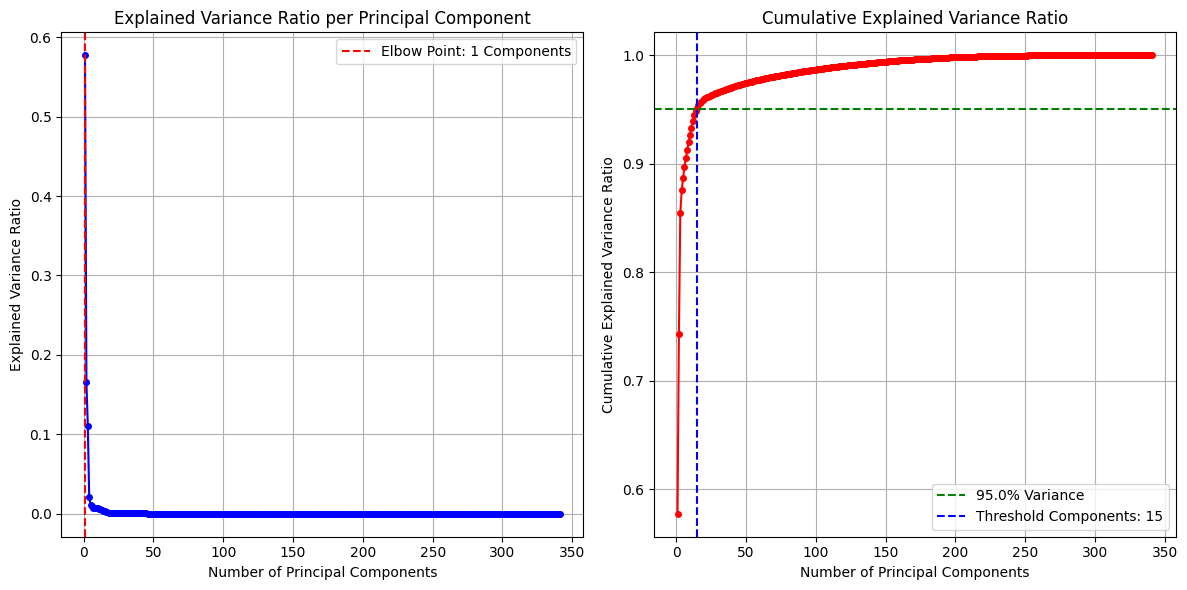

方差拐点对应的主成分数量: 1
达到95.0%方差解释率需要的主成分数量: 15
前15个主成分解释了总方差的95.15%
PCA后的特征维度: 15

类别分布:
   类别ID      训练集       测试集       验证集        总计    
--------------------------------------------------
    0       124615    41538     41539     207692  
    1        9685      3228      3230     16143   
    2        9889      3296      3298     16483   
    3       111727    37242     37244     186213  
    4       102353    34117     34119     170589  
    5       41286     13762     13762     68810   
    6       69541     23180     23182     115903  
    7       27253      9084      9086     45423   
    8       10672      3557      3559     17788   
    9        2941      980       981       4902   
    10      57074     19024     19026     95124   
    11      55357     18452     18454     92263   
    12      22326      7442      7442     37210   
    13      17004      5668      5669     28341   
    14       8418      2806      2806     14030   
    15       5664      1888      1889      9441   

Training::   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/6371 [00:00<?, ?it/s]

epoch 0/100 loss:0.0035
[训练集] acc:0.3639 balanced_acc:0.2826 f1_macro:0.2949 kappa:0.3506


  0%|          | 0/2124 [00:00<?, ?it/s]

...

[验证集] acc:0.4382 balanced_acc:0.3947 f1_macro:0.4034 kappa:0.4269
每个类别的准确率:
  类别 0: 0.9188
  类别 1: 0.3779
  类别 2: 0.4997
  类别 3: 0.8130
  类别 4: 0.7775
  类别 5: 0.5990
  类别 6: 0.7189
  类别 7: 0.7312
  类别 8: 0.7183
  类别 9: 0.3949
  类别 10: 0.8031
  类别 11: 0.4370
  类别 12: 0.4180
  类别 13: 0.4746
  类别 14: 0.4077
  类别 15: 0.4200
  类别 16: 0.5091
  类别 17: 0.6743
  类别 18: 0.2402
  类别 19: 0.1240
  类别 20: 0.5871
  类别 21: 0.6543
  类别 22: 0.5030
  类别 23: 0.6315
  类别 24: 0.5465
  类别 25: 0.6034
  类别 26: 0.2308
  类别 27: 0.0081
  类别 28: 0.1266
  类别 29: 0.3333
  类别 30: 0.3370
  类别 31: 0.2504
  类别 32: 0.1224
  类别 33: 0.3669
  类别 34: 0.3263
  类别 35: 0.1809
  类别 36: 0.1333
  类别 37: 0.4967
  类别 38: 0.3229
  类别 39: 0.5334
  类别 40: 0.5165
  类别 41: 0.4175
  类别 42: 0.2343
  类别 43: 0.0000
  类别 44: 0.2011
  类别 45: 0.2961
  类别 46: 0.2801
  类别 47: 0.2150
  类别 48: 0.1196
  类别 49: 0.5323
  类别 50: 0.0989
  类别 51: 0.5173
  类别 52: 0.5029
  类别 53: 0.5004
  类别 54: 0.4107
  类别 55: 0.1810
  类别 56: 0.2821
  类别 57: 0.2207
  类别 5

  0%|          | 0/6371 [00:00<?, ?it/s]

epoch 99/100 loss:0.0029
[训练集] acc:0.4398 balanced_acc:0.4037 f1_macro:0.4119 kappa:0.4286


  0%|          | 0/2124 [00:00<?, ?it/s]

[验证集] acc:0.4371 balanced_acc:0.3944 f1_macro:0.4034 kappa:0.4259
每个类别的准确率:
  类别 0: 0.9237
  类别 1: 0.5251
  类别 2: 0.5561
  类别 3: 0.8241
  类别 4: 0.7946
  类别 5: 0.5820
  类别 6: 0.6779
  类别 7: 0.7642
  类别 8: 0.7059
  类别 9: 0.4806
  类别 10: 0.7768
  类别 11: 0.4339
  类别 12: 0.4042
  类别 13: 0.4240
  类别 14: 0.4989
  类别 15: 0.2707
  类别 16: 0.4991
  类别 17: 0.4254
  类别 18: 0.2171
  类别 19: 0.1316
  类别 20: 0.6078
  类别 21: 0.7256
  类别 22: 0.4154
  类别 23: 0.6090
  类别 24: 0.6130
  类别 25: 0.5728
  类别 26: 0.3386
  类别 27: 0.0122
  类别 28: 0.0550
  类别 29: 0.4308
  类别 30: 0.3867
  类别 31: 0.2913
  类别 32: 0.2911
  类别 33: 0.3394
  类别 34: 0.3358
  类别 35: 0.2175
  类别 36: 0.1289
  类别 37: 0.5532
  类别 38: 0.3550
  类别 39: 0.4457
  类别 40: 0.5356
  类别 41: 0.3306
  类别 42: 0.2299
  类别 43: 0.0000
  类别 44: 0.2216
  类别 45: 0.1730
  类别 46: 0.4043
  类别 47: 0.2958
  类别 48: 0.2001
  类别 49: 0.4581
  类别 50: 0.0745
  类别 51: 0.5293
  类别 52: 0.4604
  类别 53: 0.4944
  类别 54: 0.3245
  类别 55: 0.1290
  类别 56: 0.2478
  类别 57: 0.2049
  类别 5

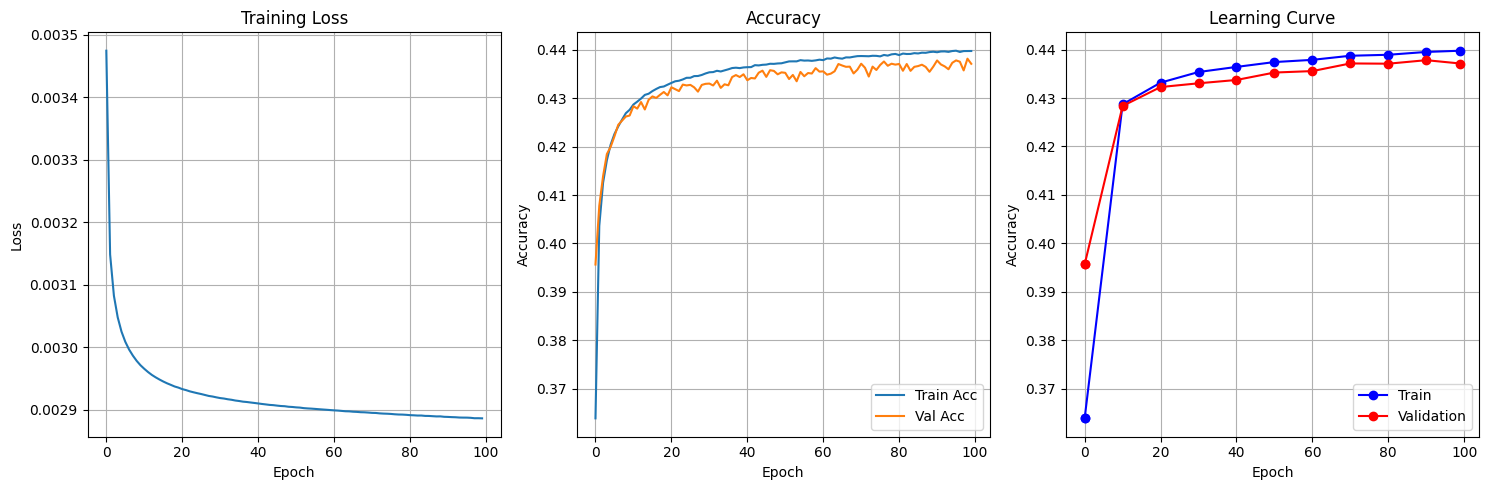

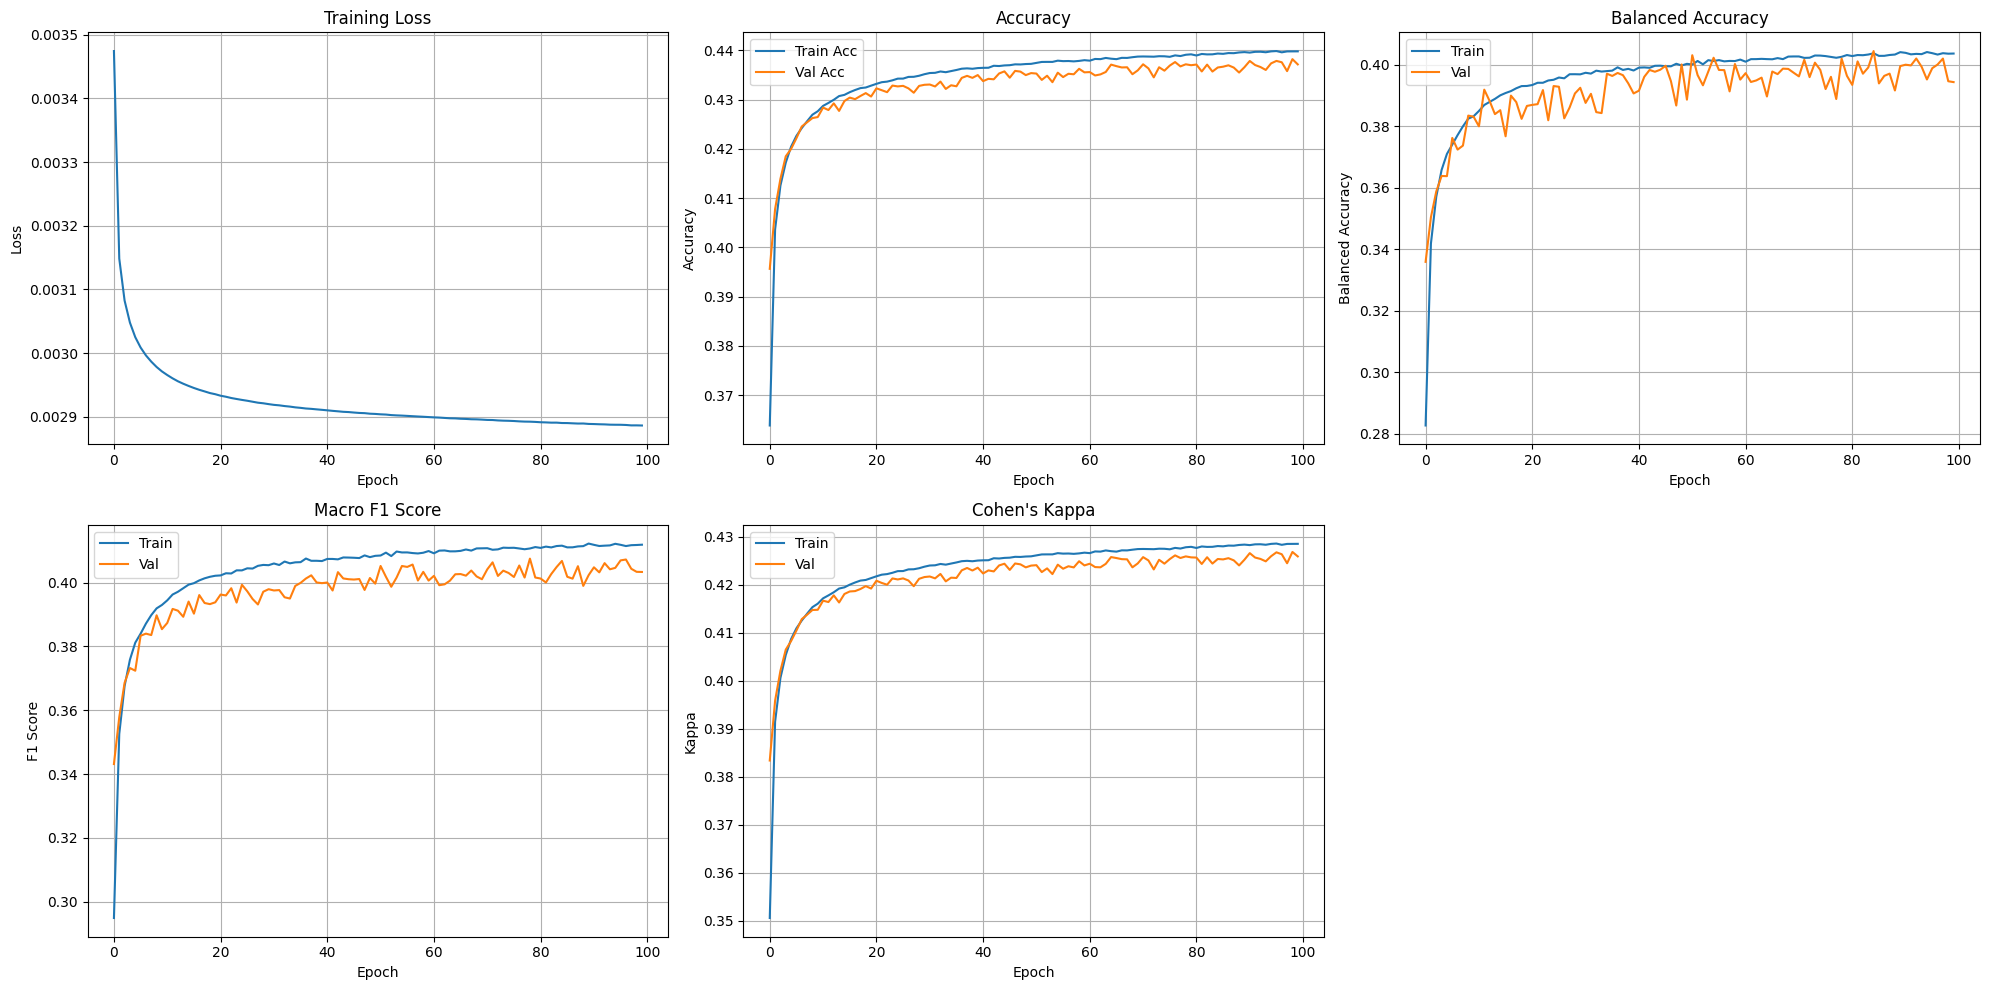

根据 acc 指标选择的最佳模型: epoch_98_acc_0.4382.pth (acc: 0.4382)


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([scalar])` or the `torch.serialization.safe_globals([scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weig

In [16]:
# Data directories
DATA_DIRS = {
    'train_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/train",
    'test_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/test",
    'val_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/val"
}
MERGED_DIR = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/merged"

# Load data from directories
print("Loading data from directories...")
dataset_dict = load_multiclass_data_from_dirs(
    DATA_DIRS, 
    apply_pca=APPLY_PCA, 
    n_components=N_PCA, 
    norm=NORM
)

# Save PCA model for later use
pca_model = dataset_dict.get('pca_model')
feature_dim = dataset_dict['feature_dim']

if pca_model is not None:
    import pickle
    pca_save_path = os.path.join(SAVE_PATH, f'pca_model_components_{feature_dim}.pkl')
    with open(pca_save_path, 'wb') as f:
        pickle.dump(pca_model, f)
    print(f"PCA model saved to: {pca_save_path}")

# Create datasets
train_dataset = MulticlassDataset(dataset_dict['train_samples'], dataset_dict['train_labels'])
test_dataset = MulticlassDataset(dataset_dict['test_samples'], dataset_dict['test_labels'])
val_dataset = MulticlassDataset(dataset_dict['val_samples'], dataset_dict['val_labels'])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Load merged dataset
print("\nLoading merged dataset...")
merged_data, merged_labels = load_merged_dataset(
    MERGED_DIR,
    apply_pca=APPLY_PCA,
    pca_model=pca_model,
    norm=NORM
)
merged_dataset = MulticlassDataset(merged_data, merged_labels)
merged_loader = DataLoader(merged_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Set computing device
device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model
model = MulticlassKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)

# Print model architecture
summary(model)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Create training info directory
training_info_dir = os.path.join(SAVE_PATH, "training_info")
os.makedirs(training_info_dir, exist_ok=True)

# Train model
print("\nStarting model training...")
training_results = train_multiclass_kan(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader, 
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=EPOCH,
    val_epoch=VAL_EPOCH,
    save_path=SAVE_PATH
)

# Plot and save training curves
plt.figure(figsize=(15, 5))

# Loss curve
plt.subplot(1, 3, 1)
plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], label='Train Acc')
plt.plot(training_results['val_epoch_list'], training_results['val_acc_list'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Learning curve (training progress)
plt.subplot(1, 3, 3)
epoch_markers = [0] + [e for e in training_results['val_epoch_list'] if e % 10 == 0 or e == training_results['val_epoch_list'][-1]]
train_acc_markers = [training_results['acc_list'][e] for e in epoch_markers]
val_acc_markers = []

for e in epoch_markers:
    if e in training_results['val_epoch_list']:
        idx = training_results['val_epoch_list'].index(e)
        val_acc_markers.append(training_results['val_acc_list'][idx])
    else:
        val_acc_markers.append(None)

plt.plot(epoch_markers, train_acc_markers, 'bo-', label='Train')
plt.plot(epoch_markers, val_acc_markers, 'ro-', label='Validation')
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
curves_path = os.path.join(training_info_dir, 'training_curves.png')
plt.savefig(curves_path, dpi=300)
print(f"Training curves saved to: {curves_path}")
plt.show()



# 在训练完成后添加这段代码或替换现有的可视化代码
plt.figure(figsize=(20, 10))

# 损失曲线
plt.subplot(2, 3, 1)
plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 准确率曲线
plt.subplot(2, 3, 2)
plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], label='Train Acc')
plt.plot(training_results['val_epoch_list'], training_results['val_acc_list'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 平衡准确率曲线
plt.subplot(2, 3, 3)
plt.plot(range(len(training_results['train_balanced_acc_list'])), training_results['train_balanced_acc_list'], label='Train')
plt.plot(training_results['val_epoch_list'], training_results['val_balanced_acc_list'], label='Val')
plt.title('Balanced Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Balanced Accuracy')
plt.legend()
plt.grid(True)

# 宏平均F1曲线
plt.subplot(2, 3, 4)
plt.plot(range(len(training_results['train_f1_macro_list'])), training_results['train_f1_macro_list'], label='Train')
plt.plot(training_results['val_epoch_list'], training_results['val_f1_macro_list'], label='Val')
plt.title('Macro F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

# Kappa系数曲线
plt.subplot(2, 3, 5)
plt.plot(range(len(training_results['train_kappa_list'])), training_results['train_kappa_list'], label='Train')
plt.plot(training_results['val_epoch_list'], training_results['val_kappa_list'], label='Val')
plt.title('Cohen\'s Kappa')
plt.xlabel('Epoch')
plt.ylabel('Kappa')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_metrics.png'), dpi=300)
plt.show()

# Get the best model
best_model_path = get_best_model(
    training_results['val_acc_list'],
    training_results['val_epoch_list'],
    SAVE_PATH,
    del_others=False  # Keep all models for now
)

# 加载最佳模型
best_model = MulticlassKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)
model_checkpoint = torch.load(best_model_path, map_location=device)
best_model.load_state_dict(model_checkpoint['state_dict'])
best_model.eval()
print(f"最佳模型已加载: {best_model_path}")

# 对所有数据集进行综合评估
print("\n正在对所有数据集进行综合评估...")
evaluation_results = evaluate_on_all_datasets_detailed(
    best_model,
    train_loader,
    test_loader,
    val_loader,
    merged_loader,
    device,
    SAVE_PATH
)

# 保存模型训练和评估摘要
summary_report = f"""# 102 类 KAN 模型 - 训练与评估摘要

## 模型信息
- 模型名称: {MODEL_NAME}
- 数据集: {DATASET}
- 类别数量: {NUM_CLASS}
- 特征维度: {feature_dim} {'(PCA 降维后)' if APPLY_PCA else ''}
- 固定网格大小: {FIXED_GRID}

## 训练参数
- 学习率: {LR}
- 权重衰减: {WEIGHT_DECAY}
- 批量大小: {BATCH_SIZE}
- 训练轮数: {len(training_results['loss_list'])}
- 计算设备: {device}

## 训练结果
- 最终训练准确率: {training_results['acc_list'][-1]:.4f}
- 最佳验证准确率: {max(training_results['val_acc_list']):.4f} (第 {training_results['val_epoch_list'][np.argmax(training_results['val_acc_list'])]} 轮)
- 最终训练宏平均F1: {training_results['train_f1_macro_list'][-1]:.4f}
- 最终训练Kappa系数: {training_results['train_kappa_list'][-1]:.4f}
- 训练时间: {training_results['train_time']:.2f} 秒

## 评估结果
- 训练集准确率: {evaluation_results['train_results']['accuracy']:.4f}
- 测试集准确率: {evaluation_results['test_results']['accuracy']:.4f}
- 验证集准确率: {evaluation_results['val_results']['accuracy']:.4f}
- 合并数据集准确率: {evaluation_results['merged_results']['accuracy']:.4f}

## 表现最佳的类别 (前 3 名)
- 训练集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['train_results']['per_class_accuracy'])[-3:][::-1]])}
- 测试集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['test_results']['per_class_accuracy'])[-3:][::-1]])}
- 验证集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['val_results']['per_class_accuracy'])[-3:][::-1]])}

## 表现较差的类别 (后 3 名)
- 训练集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['train_results']['per_class_accuracy'])[:3]])}
- 测试集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['test_results']['per_class_accuracy'])[:3]])}
- 验证集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['val_results']['per_class_accuracy'])[:3]])}

## 备注
- 该模型已在训练集、测试集、验证集和合并数据集上进行评估
- 详细的评估结果、混淆矩阵和可视化结果存储在 evaluation_results 目录中
- 最佳模型已保存，可用于推理

生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

summary_file = os.path.join(SAVE_PATH, 'model_summary.md')
with open(summary_file, 'w') as f:
    f.write(summary_report)
print(f"模型训练与评估摘要已保存: {summary_file}")

# 分析最佳模型的特征重要性
print("\n正在分析特征重要性...")
feature_importance = analyze_model_features(
    best_model,
    save_path=os.path.join(training_info_dir, 'feature_importance.png'),
    apply_pca_flag=APPLY_PCA,
    pca_model=pca_model
)

print("\n训练与评估完成！")
print(f"所有结果已保存至: {SAVE_PATH}")

In [ ]:
# 加载最佳模型
best_model = MulticlassKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)
model_checkpoint = torch.load(best_model_path, map_location=device, weights_only = False)
best_model.load_state_dict(model_checkpoint['state_dict'])
best_model.eval()
print(f"最佳模型已加载: {best_model_path}")

# 对所有数据集进行综合评估
print("\n正在对所有数据集进行综合评估...")
evaluation_results = evaluate_on_all_datasets_detailed(
    best_model,
    train_loader,
    test_loader,
    val_loader,
    merged_loader,
    device,
    SAVE_PATH
)

# 保存模型训练和评估摘要
summary_report = f"""# 102 类 KAN 模型 - 训练与评估摘要

## 模型信息
- 模型名称: {MODEL_NAME}
- 数据集: {DATASET}
- 类别数量: {NUM_CLASS}
- 特征维度: {feature_dim} {'(PCA 降维后)' if APPLY_PCA else ''}
- 固定网格大小: {FIXED_GRID}

## 训练参数
- 学习率: {LR}
- 权重衰减: {WEIGHT_DECAY}
- 批量大小: {BATCH_SIZE}
- 训练轮数: {len(training_results['loss_list'])}
- 计算设备: {device}

## 训练结果
- 最终训练准确率: {training_results['acc_list'][-1]:.4f}
- 最佳验证准确率: {max(training_results['val_acc_list']):.4f} (第 {training_results['val_epoch_list'][np.argmax(training_results['val_acc_list'])]} 轮)
- 最终训练宏平均F1: {training_results['train_f1_macro_list'][-1]:.4f}
- 最终训练Kappa系数: {training_results['train_kappa_list'][-1]:.4f}
- 训练时间: {training_results['train_time']:.2f} 秒

## 评估结果
- 训练集准确率: {evaluation_results['train_results']['accuracy']:.4f}
- 测试集准确率: {evaluation_results['test_results']['accuracy']:.4f}
- 验证集准确率: {evaluation_results['val_results']['accuracy']:.4f}
- 合并数据集准确率: {evaluation_results['merged_results']['accuracy']:.4f}

## 表现最佳的类别 (前 3 名)
- 训练集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['train_results']['per_class_accuracy'])[-3:][::-1]])}
- 测试集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['test_results']['per_class_accuracy'])[-3:][::-1]])}
- 验证集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['val_results']['per_class_accuracy'])[-3:][::-1]])}

## 表现较差的类别 (后 3 名)
- 训练集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['train_results']['per_class_accuracy'])[:3]])}
- 测试集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['test_results']['per_class_accuracy'])[:3]])}
- 验证集: {', '.join([f"类别 {i}" for i in np.argsort(evaluation_results['val_results']['per_class_accuracy'])[:3]])}

## 备注
- 该模型已在训练集、测试集、验证集和合并数据集上进行评估
- 详细的评估结果、混淆矩阵和可视化结果存储在 evaluation_results 目录中
- 最佳模型已保存，可用于推理

生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

summary_file = os.path.join(SAVE_PATH, 'model_summary.md')
with open(summary_file, 'w') as f:
    f.write(summary_report)
print(f"模型训练与评估摘要已保存: {summary_file}")

# 分析最佳模型的特征重要性
print("\n正在分析特征重要性...")
feature_importance = analyze_model_features(
    best_model,
    save_path=os.path.join(training_info_dir, 'feature_importance.png'),
    apply_pca_flag=APPLY_PCA,
    pca_model=pca_model
)

print("\n训练与评估完成！")
print(f"所有结果已保存至: {SAVE_PATH}")

最佳模型已加载: ./Results/Multiclass102_1DKAN/BrainVoxel/epoch_98_acc_0.4382.pth

正在对所有数据集进行综合评估...
在所有数据集上进行评估...
评估训练集...


NameError: name 'evaluate_multiclass_model' is not defined

In [27]:
# 可视化混淆矩阵
plt.figure(figsize=(20, 16))
conf_matrix = validation_results['confusion_matrix']

# 使用log scale可以更好地显示大量类别的混淆矩阵
plt.imshow(np.log1p(conf_matrix), cmap='Blues')
plt.colorbar(label='log(频次)')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('多分类混淆矩阵 (log scale)')

# 保存图像
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# 可视化训练过程
plt.figure(figsize=(15, 5))

# 绘制损失曲线
plt.subplot(1, 2, 1)
plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 绘制准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], label='Train Acc')
plt.plot(training_results['val_epoch_list'], training_results['val_acc_list'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_curves.png'))
plt.show()

NameError: name 'validation_results' is not defined

<Figure size 2000x1600 with 0 Axes>

In [ ]:
# 保存验证报告
validation_report = f"""
# 验证报告 - 多分类KAN (共{NUM_CLASS}类)

## 训练信息
- 训练时间: {training_results['train_time']:.2f} 秒
- 总训练轮数: {len(training_results['loss_list'])}
- 最佳模型: {os.path.basename(best_model_path)}
- 学习率: {LR}
- 批量大小: {BATCH_SIZE}
- 固定网格大小: {FIXED_GRID}

## 性能指标
- 验证集准确率: {validation_results['accuracy']:.4f}
- 最佳类别准确率: {np.max(validation_results['per_class_accuracy']):.4f} (类别 {np.argmax(validation_results['per_class_accuracy'])})
- 最差类别准确率: {np.min(validation_results['per_class_accuracy']):.4f} (类别 {np.argmin(validation_results['per_class_accuracy'])})
- 平均类别准确率: {np.mean(validation_results['per_class_accuracy']):.4f}

## 分类报告
{validation_results['report']}

## 每个类别的准确率
"""

# 添加每个类别的准确率
for i, acc in enumerate(validation_results['per_class_accuracy']):
    validation_report += f"- 类别 {i}: {acc:.4f}\n"

with open(os.path.join(SAVE_PATH, 'validation_report.txt'), 'w') as f:
    f.write(validation_report)

print(f"验证报告已保存至: {os.path.join(SAVE_PATH, 'validation_report.txt')}")

In [ ]:

# def evaluate_on_all_datasets(model, train_loader, test_loader, val_loader, device, save_path):
#     """评估模型在所有数据集上的性能"""
#     print("在所有数据集上进行评估...")
    
#     # 在训练集上评估
#     print("评估训练集...")
#     train_results = evaluate_multiclass_model(model, train_loader, device)
    
#     # 在测试集上评估
#     print("评估测试集...")
#     test_results = evaluate_multiclass_model(model, test_loader, device)
    
#     # 在验证集上评估
#     print("评估验证集...")
#     val_results = evaluate_multiclass_model(model, val_loader, device)
    
#     # 绘制所有数据集的准确率对比
#     plt.figure(figsize=(15, 10))
#     plt.suptitle(f"不同数据集性能对比", fontsize=16)
    
#     # 整体准确率对比
#     plt.subplot(2, 2, 1)
#     datasets = ['Training', 'Testing', 'Validation']
#     accuracies = [train_results['accuracy'], test_results['accuracy'], val_results['accuracy']]
#     plt.bar(datasets, accuracies, color=['blue', 'green', 'orange'])
#     plt.ylabel('Accuracy')
#     plt.title('Overall Accuracy Comparison')
#     plt.grid(axis='y')
#     for i, v in enumerate(accuracies):
#         plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
    
#     # 绘制每个类别在各个数据集上的准确率
#     plt.subplot(2, 2, 2)
#     x = np.arange(NUM_CLASS)
#     width = 0.25
    
#     plt.bar(x - width, train_results['per_class_accuracy'], width, label='Training')
#     plt.bar(x, test_results['per_class_accuracy'], width, label='Testing')
#     plt.bar(x + width, val_results['per_class_accuracy'], width, label='Validation')
    
#     plt.xlabel('Class')
#     plt.ylabel('Accuracy')
#     plt.title('Per-Class Accuracy Across Datasets')
#     plt.xticks(x, [str(i) for i in range(NUM_CLASS)], rotation=90)
#     plt.legend()
    
#     # 保存图片
#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.savefig(os.path.join(save_path, 'dataset_comparison.png'))
#     plt.show()
    
#     # 创建数据集比较报告
#     comparison_report = f"""
#     # 数据集评估性能对比报告 - 多分类KAN (共{NUM_CLASS}类)

#     ## 整体准确率
#     | 数据集 | 准确率 |
#     |--------|--------|
#     | 训练集 | {train_results['accuracy']:.4f} |
#     | 测试集 | {test_results['accuracy']:.4f} |
#     | 验证集 | {val_results['accuracy']:.4f} |
    
#     ## 类别分布
#     | 数据集 | 总样本数 | 每个类别的平均样本数 |
#     |--------|----------|----------------------|
#     | 训练集 | {len(train_loader.dataset)} | {len(train_loader.dataset) / NUM_CLASS:.1f} |
#     | 测试集 | {len(test_loader.dataset)} | {len(test_loader.dataset) / NUM_CLASS:.1f} |
#     | 验证集 | {len(val_loader.dataset)} | {len(val_loader.dataset) / NUM_CLASS:.1f} |
    
#     ## 性能差异分析
#     - 训练集与测试集准确率差异: {abs(train_results['accuracy'] - test_results['accuracy']):.4f}
#     - 训练集与验证集准确率差异: {abs(train_results['accuracy'] - val_results['accuracy']):.4f}
#     - 测试集与验证集准确率差异: {abs(test_results['accuracy'] - val_results['accuracy']):.4f}
    
#     ## 类别性能分析
#     - 训练集最佳类别: {np.argmax(train_results['per_class_accuracy'])} (准确率: {np.max(train_results['per_class_accuracy']):.4f})
#     - 训练集最差类别: {np.argmin(train_results['per_class_accuracy'])} (准确率: {np.min(train_results['per_class_accuracy']):.4f})
#     - 测试集最佳类别: {np.argmax(test_results['per_class_accuracy'])} (准确率: {np.max(test_results['per_class_accuracy']):.4f})
#     - 测试集最差类别: {np.argmin(test_results['per_class_accuracy'])} (准确率: {np.min(test_results['per_class_accuracy']):.4f})
    
#     ## 每个类别的准确率对比
#     | 类别 | 训练集准确率 | 测试集准确率 | 验证集准确率 |
#     |------|------------|------------|------------|
#     """
    
#     for i in range(NUM_CLASS):
#         comparison_report += f"| {i} | {train_results['per_class_accuracy'][i]:.4f} | {test_results['per_class_accuracy'][i]:.4f} | {val_results['per_class_accuracy'][i]:.4f} |\n"
    
#     with open(os.path.join(save_path, 'dataset_comparison_report.txt'), 'w') as f:
#         f.write(comparison_report)
    
#     print(f"数据集比较报告已保存至: {os.path.join(save_path, 'dataset_comparison_report.txt')}")
    
#     return {
#         'train_results': train_results,
#         'test_results': test_results,
#         'val_results': val_results
#     }

In [24]:
def predict_multiclass(model, data, device, apply_pca=True, pca_model=None, norm=True):
    """
    使用训练好的模型进行多分类预测
    
    参数:
        model: 训练好的KAN模型
        data: 输入数据
        device: 计算设备
        apply_pca: 是否应用PCA
        pca_model: PCA模型
        norm: 是否进行归一化
        
    返回:
        predictions: 预测的类别
        probabilities: 每个类别的概率
    """
    model.eval()
    
    # 应用PCA和归一化（如果需要）
    if apply_pca and pca_model is not None:
        data = pca_model.transform(data)
        if norm:
            data = (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0) + 1e-10)
    
    # 转换为tensor
    data_tensor = torch.FloatTensor(data).to(device)
    
    # 批处理预测
    batch_size = 64
    all_probs = []
    all_preds = []
    
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data_tensor[i:i+batch_size]
            outputs = model(batch)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    all_probs = np.vstack(all_probs)
    all_preds = np.concatenate(all_preds)
    
    return all_preds, all_probs